In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



In [3]:
df1=pd.read_csv(r"C:\Users\EXIRIM_Compurer's\Downloads\CarPrice_Assignment.csv",index_col='car_ID')
df = df1.copy()

df.shape

(205, 25)

In [5]:
df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,,,,,,,,,,,,,,,,,,,,,
1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 1 to 205
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   CarName           205 non-null    object 
 2   fueltype          205 non-null    object 
 3   aspiration        205 non-null    object 
 4   doornumber        205 non-null    object 
 5   carbody           205 non-null    object 
 6   drivewheel        205 non-null    object 
 7   enginelocation    205 non-null    object 
 8   wheelbase         205 non-null    float64
 9   carlength         205 non-null    float64
 10  carwidth          205 non-null    float64
 11  carheight         205 non-null    float64
 12  curbweight        205 non-null    int64  
 13  enginetype        205 non-null    object 
 14  cylindernumber    205 non-null    object 
 15  enginesize        205 non-null    int64  
 16  fuelsystem        205 non-null    object 
 17  bo

In [4]:
cat_cols=[col for col in df.columns if df[col].dtype=='object']
cat_cols

['CarName',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'enginetype',
 'cylindernumber',
 'fuelsystem']

In [5]:
df.isnull().sum()

symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [6]:
df.describe()


,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [7]:
num_cols=[cols for cols in df1.columns if df1[cols].dtype!='object']
num_cols

['symboling',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginesize',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg',
 'price']

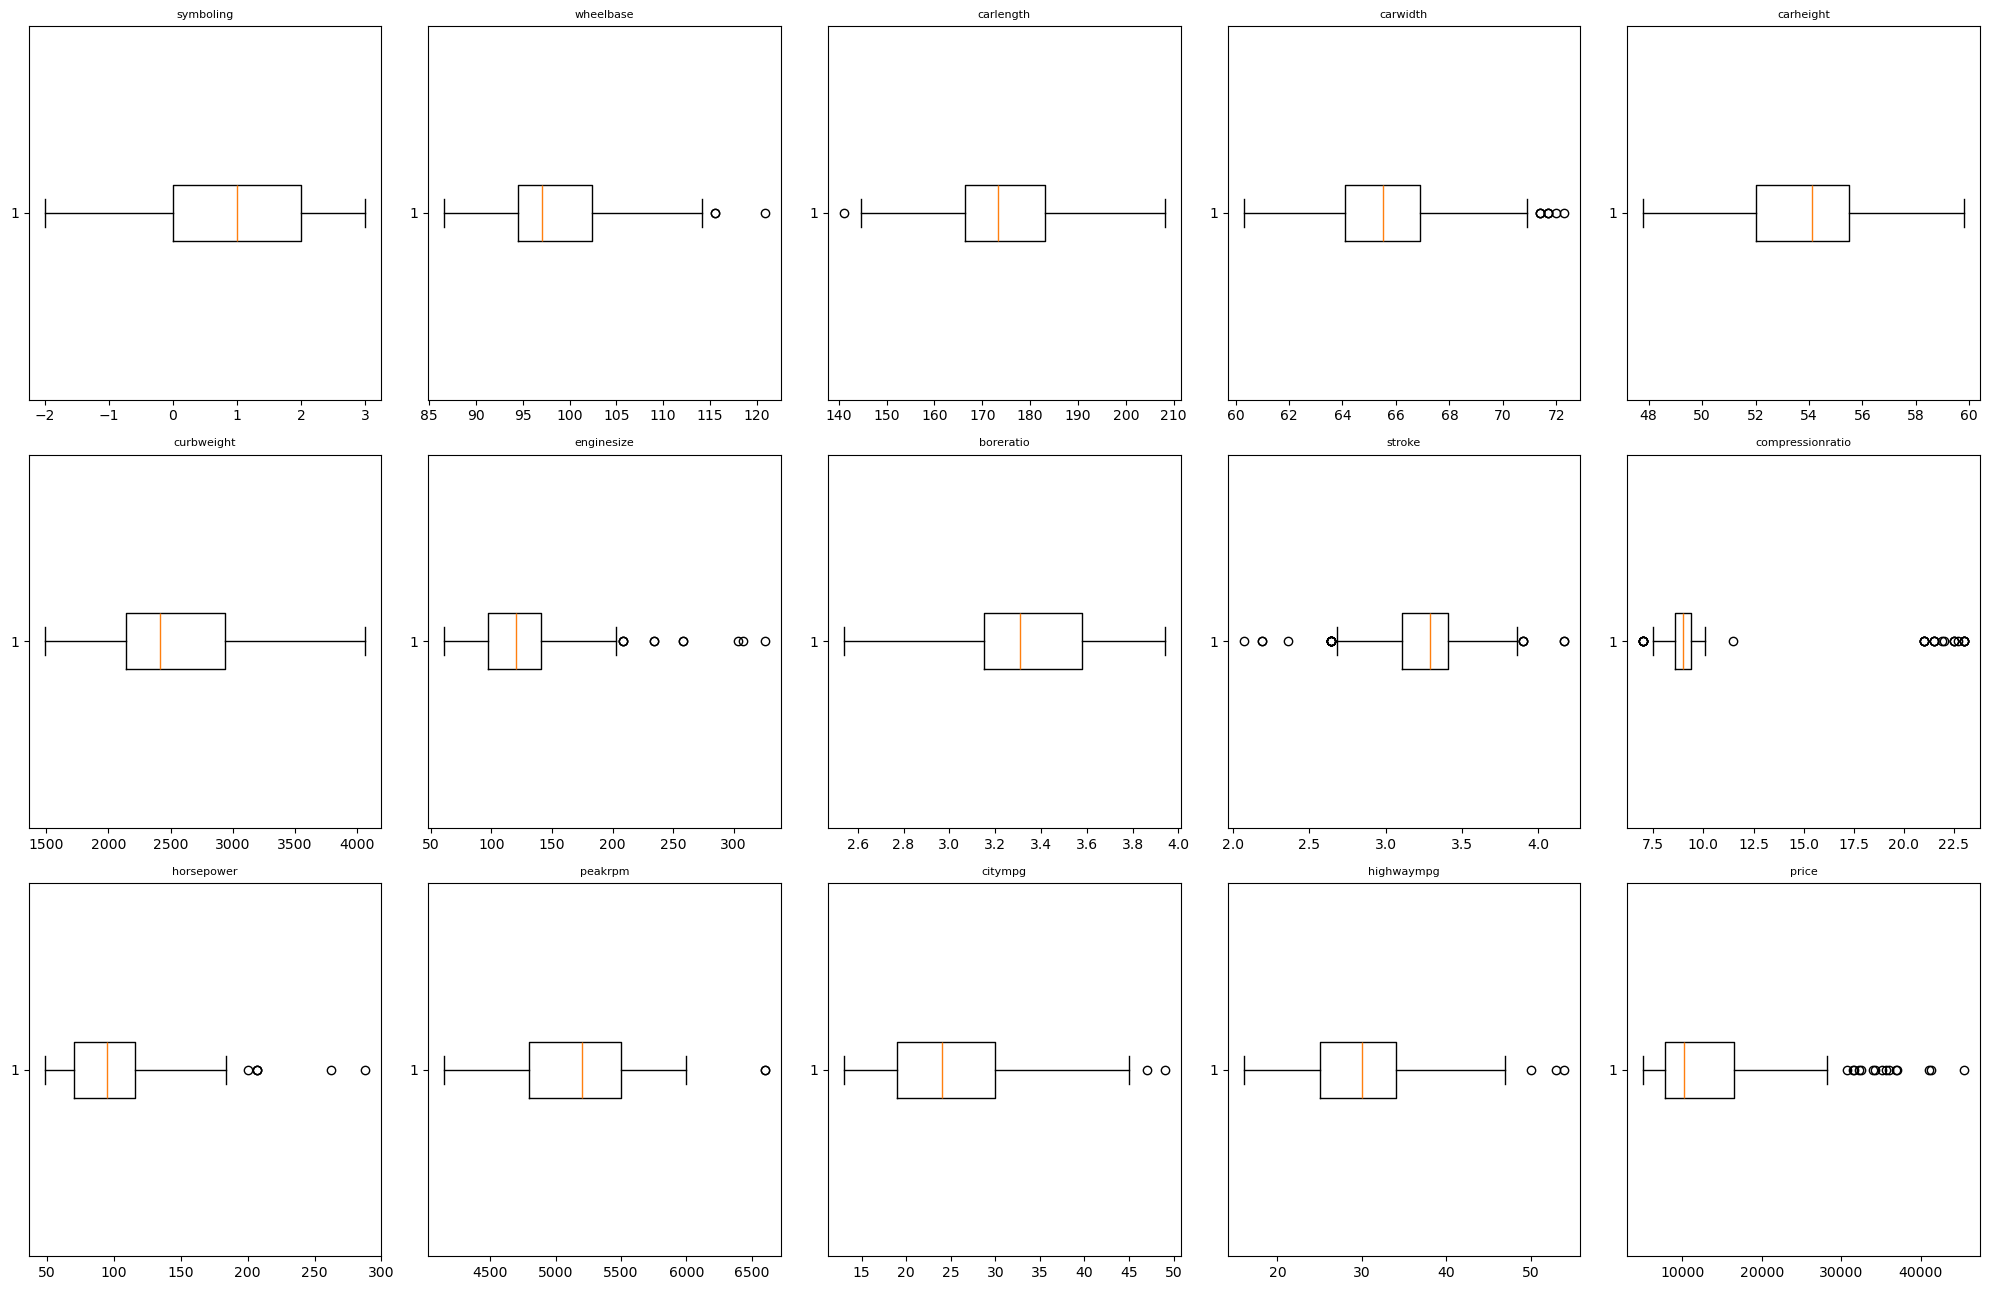

In [8]:
plt.figure(figsize=(20,13))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 5, i)   
    plt.boxplot(df[col],vert=False)
    plt.title(col, fontsize=8)
    plt.tight_layout()

plt.show()


In [9]:
out_cols=df[['wheelbase','carwidth','enginesize','stroke','compressionratio','horsepower','peakrpm','citympg','highwaympg']]
out_cols

,wheelbase,carwidth,enginesize,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
car_ID,,,,,,,,,
1,88.6,64.1,130,2.68,9.0,111,5000,21,27
2,88.6,64.1,130,2.68,9.0,111,5000,21,27
3,94.5,65.5,152,3.47,9.0,154,5000,19,26
4,99.8,66.2,109,3.40,10.0,102,5500,24,30
5,99.4,66.4,136,3.40,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...
201,109.1,68.9,141,3.15,9.5,114,5400,23,28
202,109.1,68.8,141,3.15,8.7,160,5300,19,25
203,109.1,68.9,173,2.87,8.8,134,5500,18,23


In [10]:
 # və ya read_csv-dən gələn df

outlier_count = np.zeros(len(df), dtype=int)

for col in out_cols:
    q1, q3 = np.percentile(df[col], [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    
    outlier_count += ~df[col].between(lower, upper)

# məsələn max 2 outlier olan sətrlər qalsın
df_clean = df[outlier_count <=1]
df_clean.shape


(193, 25)

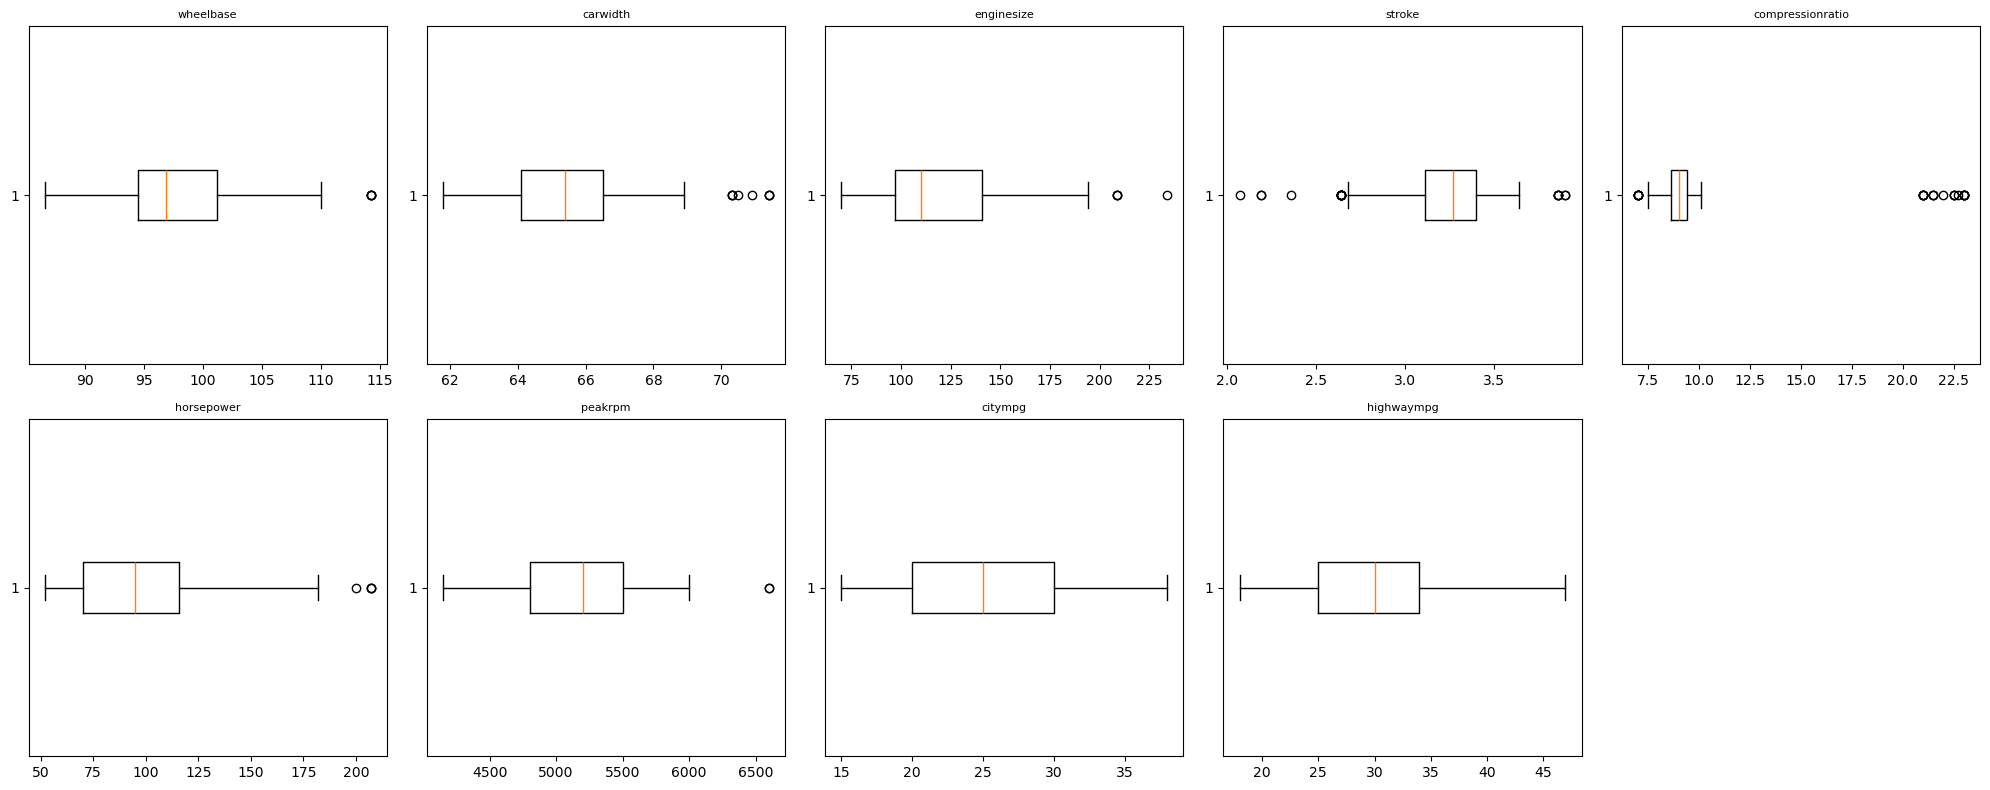

In [11]:
plt.figure(figsize=(20,8))

for i, col in enumerate(out_cols, 1):
    plt.subplot(2, 5, i)   
    plt.boxplot(df_clean[col],vert=False)
    plt.title(col, fontsize=8)
    plt.tight_layout()

plt.show()

In [12]:
df_clean=df_clean.drop(['CarName','fueltype'],axis=1)

In [13]:
cat_cols.remove('CarName')
cat_cols.remove('fueltype')

In [14]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
out_o_h=[cols for cols in df_clean[cat_cols] if cols in ['fuelsystem','cylindernumber','enginetype','carbody']]
out_l_e=[ftrs for ftrs in cat_cols if ftrs not in out_o_h ]
out_o_h

['carbody', 'enginetype', 'cylindernumber', 'fuelsystem']

In [15]:
df_clean = pd.get_dummies(df_clean, columns=out_o_h, drop_first=True)


In [16]:
df_clean.shape

(193, 38)

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le=LabelEncoder()
for c in out_l_e:
    df_clean[c]=le.fit_transform(df_clean[c])

In [19]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 1 to 205
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   symboling            193 non-null    int64  
 1   aspiration           193 non-null    int64  
 2   doornumber           193 non-null    int64  
 3   drivewheel           193 non-null    int64  
 4   enginelocation       193 non-null    int64  
 5   wheelbase            193 non-null    float64
 6   carlength            193 non-null    float64
 7   carwidth             193 non-null    float64
 8   carheight            193 non-null    float64
 9   curbweight           193 non-null    int64  
 10  enginesize           193 non-null    int64  
 11  boreratio            193 non-null    float64
 12  stroke               193 non-null    float64
 13  compressionratio     193 non-null    float64
 14  horsepower           193 non-null    int64  
 15  peakrpm              193 non-null    int64  


In [20]:
df_clean.shape

(193, 38)

In [21]:
df_clean.corr()

,symboling,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,...,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
symboling,1.000000,-0.070829,0.663054,0.001287,0.217480,-0.529177,-0.320547,-0.188532,-0.549123,-0.178178,...,-0.064675,-0.092493,0.018586,0.251787,-0.051907,0.217480,-0.188880,0.046183,0.185459,0.066957
aspiration,-0.070829,1.000000,-0.028569,0.080298,-0.059141,0.306116,0.266615,0.365327,0.091571,0.394167,...,0.193325,-0.009912,-0.084190,-0.068471,-0.335395,-0.059141,0.403961,-0.021005,0.406124,-0.033967
doornumber,0.663054,-0.028569,1.000000,0.125477,0.144658,-0.452262,-0.396944,-0.219416,-0.548303,-0.189234,...,-0.061406,-0.082101,0.050677,0.167477,-0.021112,0.144658,-0.206609,-0.008719,0.155336,0.083082
drivewheel,0.001287,0.080298,0.125477,1.000000,0.157840,0.415459,0.444819,0.417078,-0.025918,0.543829,...,-0.086995,-0.325986,0.362063,0.182740,-0.433793,0.157840,0.144975,0.365568,-0.077860,0.090653
enginelocation,0.217480,-0.059141,0.144658,0.157840,1.000000,-0.210389,-0.051423,-0.050005,-0.112647,0.071093,...,-0.029374,-0.258015,0.350325,-0.018280,-0.089544,-0.015789,-0.040300,0.138700,-0.027790,-0.009068
wheelbase,-0.529177,0.306116,-0.452262,0.415459,-0.210389,1.000000,0.845259,0.773144,0.643515,0.728433,...,0.261103,-0.204484,0.114625,-0.084657,-0.400434,-0.073122,0.358023,0.318518,-0.121757,-0.032482
carlength,-0.320547,0.266615,-0.396944,0.444819,-0.051423,0.845259,1.000000,0.826553,0.537602,0.857767,...,0.262844,-0.342315,0.256768,-0.058228,-0.495219,-0.050294,0.240297,0.501861,-0.079247,-0.005543
carwidth,-0.188532,0.365327,-0.219416,0.417078,-0.050005,0.773144,0.826553,1.000000,0.336478,0.836145,...,0.443331,-0.465503,0.226955,-0.003045,-0.534542,-0.002630,0.285982,0.445995,-0.035071,-0.020946
carheight,-0.549123,0.091571,-0.548303,-0.025918,-0.112647,0.643515,0.537602,0.336478,1.000000,0.363451,...,0.138386,0.067128,-0.047102,-0.251052,-0.092917,-0.216844,0.282055,0.118259,-0.294038,-0.070682
curbweight,-0.178178,0.394167,-0.189234,0.543829,0.071093,0.728433,0.857767,0.836145,0.363451,1.000000,...,0.286200,-0.525127,0.423565,-0.033152,-0.604572,-0.036844,0.272610,0.511942,0.017198,0.034988


In [22]:
df_clean = df_clean.loc[:, abs(df_clean.corr()['price']) > 0.01]

In [23]:
df_clean.corr()['price'].sort_values(ascending=False)

price                  1.000000
enginesize             0.820709
horsepower             0.792935
curbweight             0.785094
carwidth               0.673177
carlength              0.615635
cylindernumber_six     0.557462
drivewheel             0.554277
fuelsystem_mpfi        0.519056
boreratio              0.509042
wheelbase              0.451507
enginelocation         0.418916
cylindernumber_five    0.288886
aspiration             0.249240
enginetype_ohcv        0.214070
carbody_hardtop        0.188829
carheight              0.146158
fuelsystem_idi         0.145224
enginetype_l           0.112847
compressionratio       0.102477
carbody_sedan          0.080721
enginetype_ohcf        0.056520
stroke                 0.015860
enginetype_rotor       0.012539
cylindernumber_two     0.012539
doornumber            -0.013718
fuelsystem_spfi       -0.015269
fuelsystem_spdi       -0.048714
enginetype_ohc        -0.247818
carbody_hatchback     -0.249492
fuelsystem_2bbl       -0.531036
cylinder

In [24]:
X=df_clean.drop(['price'],axis=1)
y=df_clean['price']

In [25]:
X

,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,...,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_two,fuelsystem_2bbl,fuelsystem_idi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
car_ID,,,,,,,,,,,,,,,,,,,,,
1,0,1,2,0,88.6,168.8,64.1,48.8,2548,130,...,False,False,True,False,False,False,False,True,False,False
2,0,1,2,0,88.6,168.8,64.1,48.8,2548,130,...,False,False,True,False,False,False,False,True,False,False
3,0,1,2,0,94.5,171.2,65.5,52.4,2823,152,...,False,False,False,True,False,False,False,True,False,False
4,0,0,1,0,99.8,176.6,66.2,54.3,2337,109,...,False,False,True,False,False,False,False,True,False,False
5,0,0,0,0,99.4,176.6,66.4,54.3,2824,136,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,0,0,2,0,109.1,188.8,68.9,55.5,2952,141,...,False,False,True,False,False,False,False,True,False,False
202,1,0,2,0,109.1,188.8,68.8,55.5,3049,141,...,False,False,True,False,False,False,False,True,False,False
203,0,0,2,0,109.1,188.8,68.9,55.5,3012,173,...,False,False,False,True,False,False,False,True,False,False


In [26]:
y

car_ID
1      13495.0
2      16500.0
3      16500.0
4      13950.0
5      17450.0
        ...   
201    16845.0
202    19045.0
203    21485.0
204    22470.0
205    22625.0
Name: price, Length: 193, dtype: float64

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)


(154, 33)
(39, 33)


In [28]:
print(y_train.shape)
print(y_test.shape)

(154,)
(39,)


In [29]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [30]:
X_train[:2]

array([[-0.49186938, -0.80988516, -0.58958984, -0.11470787, -0.75393928,
        -0.33666568, -1.04497475, -0.16755315, -1.07523436, -0.81151138,
        -0.67028139,  0.17773338, -0.20784017, -0.96370006,  0.99583957,
         1.01154282, -0.16329932, -0.69337525, -0.98709623, -0.26352314,
         0.60235526, -0.29070095, -0.23408229, -0.16329932, -0.23408229,
         0.48166378, -0.34050261, -0.16329932,  1.42112907, -0.34050261,
        -0.88921183, -0.20134682, -0.08084521],
       [-0.49186938, -0.80988516, -0.58958984, -0.11470787, -0.90033064,
        -1.48900897, -1.04497475, -1.39225426, -1.19958591, -1.04623348,
        -1.36486832, -0.01638677, -0.20784017, -0.99501675,  0.99583957,
         1.17744015, -0.16329932,  1.44222051, -0.98709623, -0.26352314,
         0.60235526, -0.29070095, -0.23408229, -0.16329932, -0.23408229,
         0.48166378, -0.34050261, -0.16329932,  1.42112907, -0.34050261,
        -0.88921183, -0.20134682, -0.08084521]])

In [31]:
linear=LinearRegression()
linear.fit(X_train,y_train)
y_pred=linear.predict(X_test)

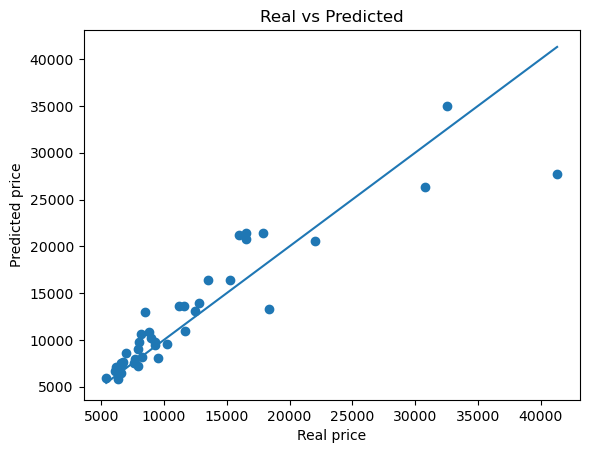

In [32]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Real price")
plt.ylabel("Predicted price")
plt.title("Real vs Predicted")
plt.show()


In [33]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [34]:
print("MSE:",mean_squared_error(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("R2:",r2_score(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred)**0.5)

MSE: 9951208.440121436
MAE: 2052.2773756202114
R2: 0.8338771193836876
RMSE: 3154.5536039385092


In [35]:
y_tr_pred=linear.predict(X_train)
y_tst_pred=linear.predict(X_test)
r2_tr=r2_score(y_train,y_tr_pred)
r2_tst=r2_score(y_test,y_tst_pred)
print("R2 train:",r2_tr)
print("R2 test:",r2_tst)

R2 train: 0.925110430165512
R2 test: 0.8338771193836876


In [36]:
from sklearn.linear_model import Ridge


rg = Ridge(alpha=1)


rg.fit(X_train, y_train)


y_train_pred = rg.predict(X_train)
y_test_pred  = rg.predict(X_test)


r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

print("R2 train:", r2_train)
print("R2 test :", r2_test)


R2 train: 0.9229729353169578
R2 test : 0.8367700079396334


In [37]:
from sklearn.svm import SVR

In [38]:
svr=SVR(kernel='linear', C=1000)
svr.fit(X_train,y_train)
y_pred_svr=svr.predict(X_test)


In [39]:
print("MSE:",mean_squared_error(y_test,y_pred_svr))
print("MAE:",mean_absolute_error(y_test,y_pred_svr))
print("R2:",r2_score(y_test,y_pred_svr))
print("RMSE:",mean_squared_error(y_test,y_pred_svr)**0.5)

MSE: 11241600.673238268
MAE: 2190.923449283637
R2: 0.8123356476940775
RMSE: 3352.8496347492633


In [40]:
y_tr_pred_svr=svr.predict(X_train)
y_tst_pred_svr=svr.predict(X_test)
r2_tr_svr=r2_score(y_train,y_tr_pred_svr)
r2_tst_svr=r2_score(y_test,y_tst_pred_svr)
print("R2 train:",r2_tr_svr)
print("R2 test:",r2_tst_svr)

R2 train: 0.9021527200907344
R2 test: 0.8123356476940775


In [41]:
from sklearn import tree

In [52]:
tre=tree.DecisionTreeRegressor()
tre.fit(X_train,y_train)
y_pred_tre=tre.predict(X_test)

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid={
    'max_depth':[3,5,10,15],
    'min_samples_leaf':[2,3,5],
     'max_features':[5,10,20]
}

grid_search=GridSearchCV(estimator=tre,param_grid=param_grid,cv=5,scoring='accuracy',verbose=3,n_jobs=-1)

grid_search.fit(X_train,y_train)

print(grid_search.best_params_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'max_depth': 3, 'max_features': 5, 'min_samples_leaf': 2}
DecisionTreeRegressor(max_depth=3, max_features=5, min_samples_leaf=2)


C:\anacondapyt\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [57]:
best_model=grid_search.best_estimator_

y_pred_tre=best_model.predict(X_test)

In [58]:
print("MSE:",mean_squared_error(y_test,y_pred_tre))
print("MAE:",mean_absolute_error(y_test,y_pred_tre))
print("R2:",r2_score(y_test,y_pred_tre))
print("RMSE:",mean_squared_error(y_test,y_pred_tre)**0.5)

MSE: 8629813.227494463
MAE: 2297.429621082621
R2: 0.8559361467344923
RMSE: 2937.6543750915394


In [62]:
y_tr_pred_tre=best_model.predict(X_train)
y_tst_pred_tre=best_model.predict(X_test)
r2_tr_tre=r2_score(y_train,y_tr_pred_tre)
r2_tst_tre=r2_score(y_test,y_tst_pred_tre)
print("R2 train:",r2_tr_tre)
print("R2 test:",r2_tst_tre)

R2 train: 0.8888858180238929
R2 test: 0.8559361467344923
